In [43]:
import struct
import numpy as np
import pandas as pd

def read_header(f):
    """3개 파일에 공통으로 적용되는 헤더(이온 개수 및 이름)를 읽는 함수"""
    header_data = f.read(16) # G4int(4바이트) * 4개 = 16바이트
    if not header_data:
        return None
    
    nX, nY, nZ, numIons = struct.unpack('iiii', header_data)
    
    ion_names = []
    for _ in range(numIons):
        # 1. 이온 이름의 길이 (4바이트 int) 읽기
        name_len = struct.unpack('i', f.read(4))[0]
        # 2. 길이만큼 문자열 읽어서 디코딩
        name = f.read(name_len).decode('utf-8')
        ion_names.append(name)
        
    return nX, nY, nZ, numIons, ion_names

def parse_dose_binary(filename):
    """Dose.out 바이너리 파일을 읽어서 DataFrame으로 반환"""
    with open(filename, 'rb') as f:
        header = read_header(f)
        if not header: return None
        nX, nY, nZ, numIons, ion_names = header
        
        # 데이터 구조(dtype) 정의
        # i4: 32-bit int, f8: 64-bit double, u4: 32-bit unsigned int
        dtype_spec = [('i', 'i4'), ('j', 'i4'), ('k', 'i4'), 
                      ('Total_Dose_Gy', 'f8'), ('Total_Dose_SE_Gy', 'f8')]
        
        for name in ion_names:
            dtype_spec.extend([
                (f'{name}_Dose', 'f8'),
                (f'{name}_Dose_SE', 'f8'),
                (f'{name}_f', 'u4') # Fluence
            ])
            
        # numpy를 이용해 남은 데이터를 한 번에 빛의 속도로 읽어들임
        dt = np.dtype(dtype_spec)
        data = np.frombuffer(f.read(), dtype=dt)
        
    return pd.DataFrame(data)

def parse_lineal_binary(filename):
    """LinealEnergy.out 바이너리 파일을 읽어서 DataFrame으로 반환"""
    with open(filename, 'rb') as f:
        header = read_header(f)
        if not header: return None
        nX, nY, nZ, numIons, ion_names = header
        
        dtype_spec = [('i', 'i4'), ('j', 'i4'), ('k', 'i4'), 
                      ('Total_yD', 'f8'), ('Total_yD_SE', 'f8')]
        
        for name in ion_names:
            dtype_spec.extend([
                (f'{name}_yD', 'f8'),
                (f'{name}_yD_SE', 'f8'),
                (f'{name}_f', 'u4') # Fluence
            ])
            
        dt = np.dtype(dtype_spec)
        data = np.frombuffer(f.read(), dtype=dt)
        
    return pd.DataFrame(data)

def parse_let_binary(filename):
    """LET.out 바이너리 파일을 읽어서 DataFrame으로 반환"""
    with open(filename, 'rb') as f:
        header = read_header(f)
        if not header: return None
        nX, nY, nZ, numIons, ion_names = header
        
        # LET 파일은 Total 변수가 4개 (Dose N/SE, Track N/SE)
        dtype_spec = [('i', 'i4'), ('j', 'i4'), ('k', 'i4'), 
                      ('Total_LDT', 'f8'), ('Total_LDT_SE', 'f8'),
                      ('Total_LTT', 'f8'), ('Total_LTT_SE', 'f8')]
        
        for name in ion_names:
            # 앞서 작성한 C++ 코드에서 LET는 Fluence(u4)를 파일에 쓰지 않았으므로 f8 4개만 읽음
            dtype_spec.extend([
                (f'{name}_LDT', 'f8'),
                (f'{name}_LDT_SE', 'f8'),
                (f'{name}_LTT', 'f8'),
                (f'{name}_LTT_SE', 'f8')
            ])
            
        dt = np.dtype(dtype_spec)
        data = np.frombuffer(f.read(), dtype=dt)
        
    return pd.DataFrame(data)

import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기 (이미 df 변수로 데이터프레임이 있다면 생략)
# df = pd.read_csv('변환된_파일_이름.csv')

import pandas as pd
import matplotlib.pyplot as plt

def plot_profile_with_error(df, x_axis, fixed_axes, target_col, error_col, y_label="Lineal Energy, yD (keV/μm)"):
    """
    지정된 축들을 고정하고, 한 축을 따라 에러바가 포함된 그래프를 그리는 함수
    
    :param df: pandas 데이터프레임
    :param x_axis: x축으로 사용할 인덱스 컬럼 이름 (예: 'i')
    :param fixed_axes: 고정할 인덱스와 값의 딕셔너리 (예: {'j': 0, 'k': 0})
    :param target_col: y축에 그릴 값 컬럼 이름 (예: 'Total_yD')
    :param error_col: 에러바(표준오차) 컬럼 이름 (예: 'Total_yD_SE')
    :param y_label: Y축 라벨 및 단위 지정 (기본값: Lineal Energy 단위)
    """
    
    # 1. 데이터 필터링
    filtered_df = df.copy()
    for axis, value in fixed_axes.items():
        filtered_df = filtered_df[filtered_df[axis] == value]
        
    # x축을 기준으로 데이터 정렬
    filtered_df = filtered_df.sort_values(by=x_axis)
    
    # 2. 데이터 유효성 검사
    if filtered_df.empty:
        print(f"조건 {fixed_axes}에 맞는 데이터가 없습니다!")
        return

    # 3. x, y, yerr 데이터 추출
    x = filtered_df[x_axis]
    y = filtered_df[target_col]
    yerr = filtered_df[error_col]
    
    # 4. 그래프 그리기 세팅
    plt.figure(figsize=(10, 6))
    
    # 에러바 플롯 생성
    plt.errorbar(x, y, yerr=yerr, fmt='-o', color='blue', ecolor='red', 
                 capsize=3, capthick=1, markersize=3, label=target_col)
    
    # 5. 그래프 꾸미기
    fixed_str = ", ".join([f"{k}={v}" for k, v in fixed_axes.items()])
    plt.title(f"Profile of {target_col} along '{x_axis}' axis\n(Fixed: {fixed_str})", fontsize=14)
    plt.xlabel(f"Voxel Index '{x_axis}'", fontsize=12)
    
    # 👉 수정된 부분: 파라미터로 받은 y_label을 사용합니다.
    plt.ylabel(y_label, fontsize=12) 
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    
    # 6. 출력
    plt.show()

In [44]:
try:
    df_dose = parse_dose_binary("Dose_22.out")
    print(df_dose.head(n=5)) # 상위 5개 데이터 출력
    print(df_dose.shape) 
except FileNotFoundError:
    print("Dose.out 파일을 찾을 수 없습니다.")

   i  j  k  Total_Dose_Gy  Total_Dose_SE_Gy  proton_1_Dose  proton_1_Dose_SE  \
0  0  0  0   1.215085e-17      1.694325e-26   1.202062e-17      1.485213e-26   
1  1  0  0   1.894734e-17      2.322721e-26   1.881442e-17      2.185532e-26   
2  2  0  0   2.618746e-17      2.793481e-26   2.604964e-17      2.674936e-26   
3  3  0  0   3.355596e-17      3.250761e-26   3.341713e-17      3.145325e-26   
4  4  0  0   4.083542e-17      3.613613e-26   4.069531e-17      3.514702e-26   

   proton_1_f  deuteron_Dose  deuteron_Dose_SE  ...  O18_f      F17_Dose  \
0     1002497   8.822536e-21      7.166048e-24  ...      0  0.000000e+00   
1     1002736   1.390040e-20      6.927877e-24  ...      2  0.000000e+00   
2     1002903   1.370302e-20      5.456472e-24  ...      0  0.000000e+00   
3     1002985   1.209062e-20      6.346697e-24  ...      1  0.000000e+00   
4     1002934   1.304480e-20      5.434165e-24  ...      0  6.228297e-24   

   F17_Dose_SE  F17_f  F18_Dose  F18_Dose_SE  F18_f     Ne20_D

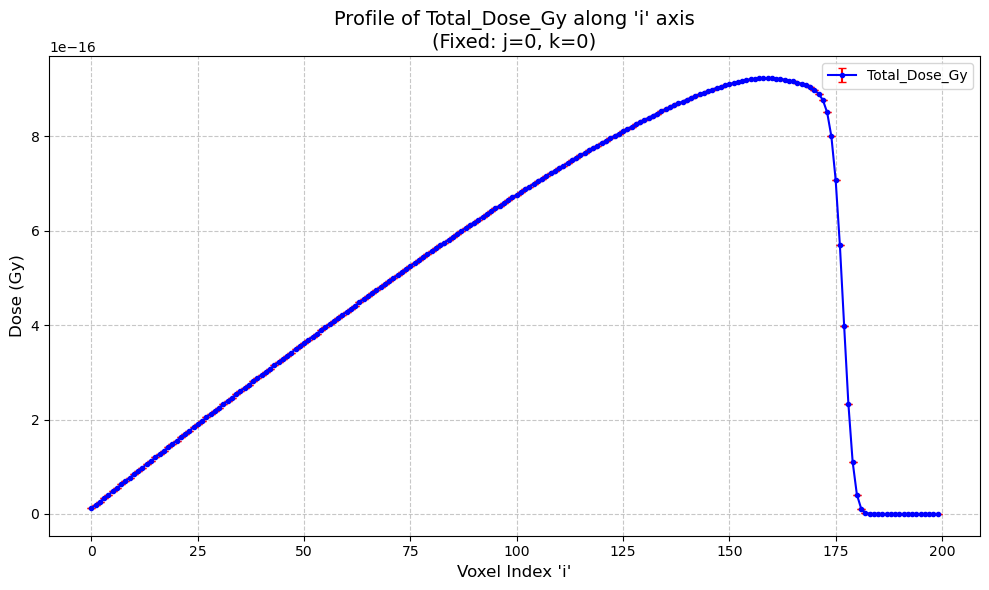

In [46]:
plot_profile_with_error(
    df=df_dose,
    x_axis='i',                     # x축에 들어갈 컬럼
    fixed_axes={'j': 0, 'k': 0},    # 고정할 축
    target_col='Total_Dose_Gy',     # 값 컬럼
    error_col='Total_Dose_SE_Gy',    # 에러바 컬럼
    y_label= "Dose (Gy)"
)


In [37]:
print("\nReading LET file...")
try:
    df_let = parse_let_binary("LET_22.out")
    print(df_let.head())
    print(df_let.shape) 
except FileNotFoundError:
    print("LET.out 파일을 찾을 수 없습니다.")


Reading LET file...
   i  j  k  Total_LDT  Total_LDT_SE  Total_LTT  Total_LTT_SE  proton_1_LDT  \
0  0  0  0   4.208895      0.152569   0.534964      0.000576      0.624432   
1  1  0  0   2.795460      0.092939   0.539060      0.000586      0.603827   
2  2  0  0   2.263999      0.069363   0.542722      0.000602      0.592719   
3  3  0  0   1.896767      0.056480   0.545626      0.000622      0.585295   
4  4  0  0   1.631261      0.044465   0.548444      0.000643      0.578459   

   proton_1_LDT_SE  proton_1_LTT  ...     F17_LTT  F17_LTT_SE  F18_LDT  \
0         0.004197      0.526406  ...    0.000000    0.000000      0.0   
1         0.002938      0.530393  ...    0.000000    0.000000      0.0   
2         0.002237      0.533818  ...    0.000000    0.000000      0.0   
3         0.001856      0.536649  ...    0.000000    0.000000      0.0   
4         0.001560      0.539394  ...  207.655773    0.000004      0.0   

   F18_LDT_SE  F18_LTT  F18_LTT_SE    Ne20_LDT  Ne20_LDT_SE    Ne

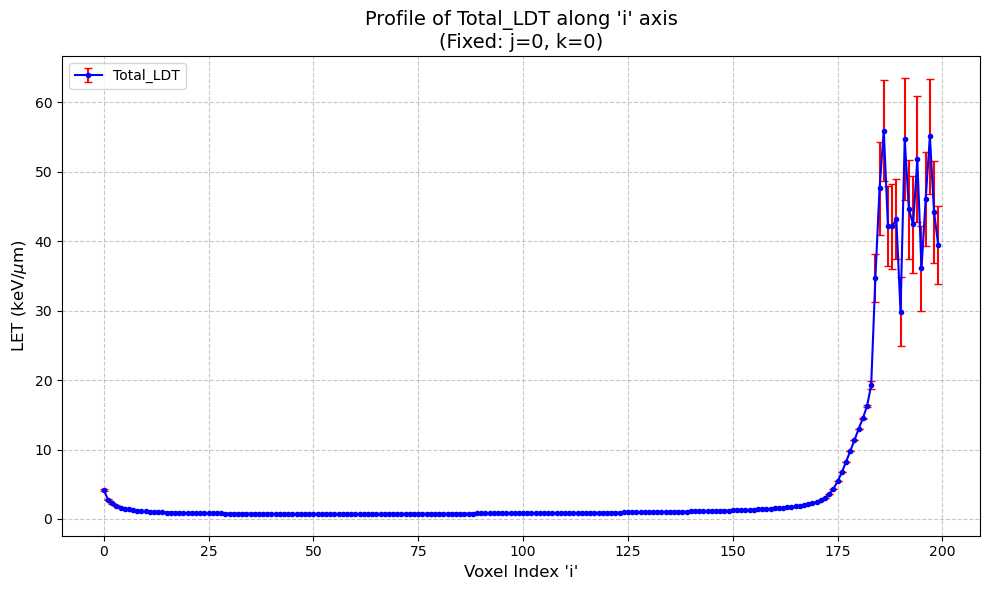

In [53]:
plot_profile_with_error(
    df=df_let,
    x_axis='i',                     # x축에 들어갈 컬럼
    fixed_axes={'j': 0, 'k': 0},    # 고정할 축
    target_col='Total_LDT',     # 값 컬럼
    error_col='Total_LDT_SE',    # 에러바 컬럼
    y_label= "LET ($\\text{keV}/\mu\\text{m}$)"
)


In [40]:
print("\nReading Lineal Energy file...")
try:
    df_lineal = parse_lineal_binary("Test_LinealEnergy.out")
    print(df_lineal.head())
    print(df_lineal.shape) 
except FileNotFoundError:
    print("LinealEnergy.out 파일을 찾을 수 없습니다.")




Reading Lineal Energy file...
   i  j  k    Total_yD  Total_yD_SE  proton_1_yD  proton_1_yD_SE  proton_1_f  \
0  0  0  0  320.646324    48.875666   272.582038       44.794853     1002365   
1  1  0  0  417.454163    13.398054   383.758151       12.573187     1002560   
2  2  0  0  523.741058    19.877262   501.423508       19.812349     1002765   
3  3  0  0  589.446110     7.127641   571.742331        6.998781     1002835   
4  4  0  0  683.400962    11.752394   668.381639       11.621391     1002854   

   deuteron_yD  deuteron_yD_SE  ...  O18_f  F17_yD  F17_yD_SE  F17_f  F18_yD  \
0  1199.246654      121.347603  ...      3     0.0        0.0      0     0.0   
1  1466.777728      105.814661  ...      0     0.0        0.0      0     0.0   
2  1553.345352      114.204125  ...      2     0.0        0.0      0     0.0   
3  1421.102676      169.633920  ...      1     0.0        0.0      0     0.0   
4  1297.905216      104.410677  ...      1     0.0        0.0      0     0.0   

   F18_

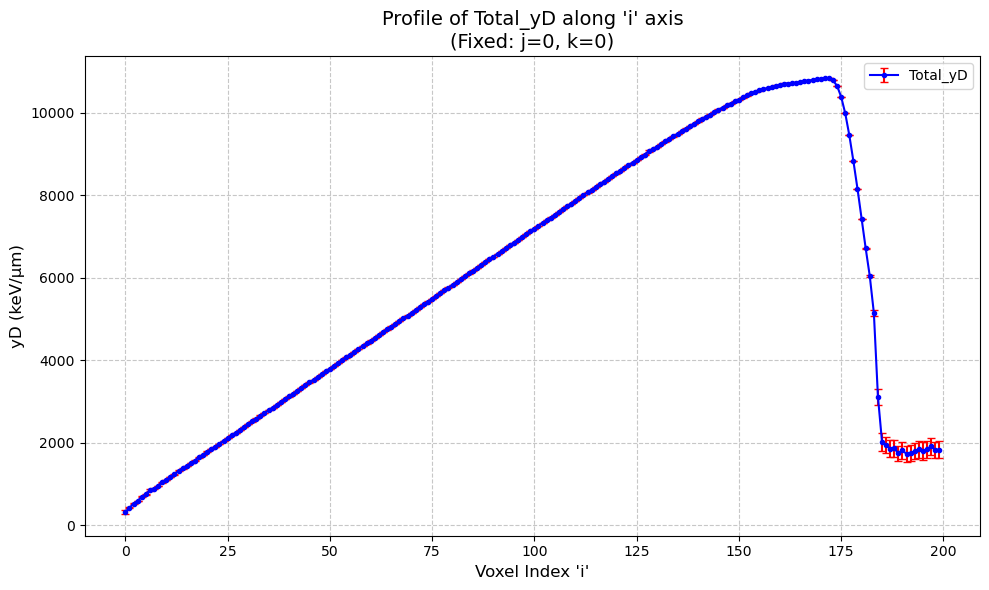

In [56]:
plot_profile_with_error(
    df=df_lineal,
    x_axis='i',                     # x축에 들어갈 컬럼
    fixed_axes={'j': 0, 'k': 0},    # 고정할 축
    target_col='Total_yD',     # 값 컬럼
    error_col='Total_yD_SE',    # 에러바 컬럼
    y_label= "yD (keV/μm)"
)
